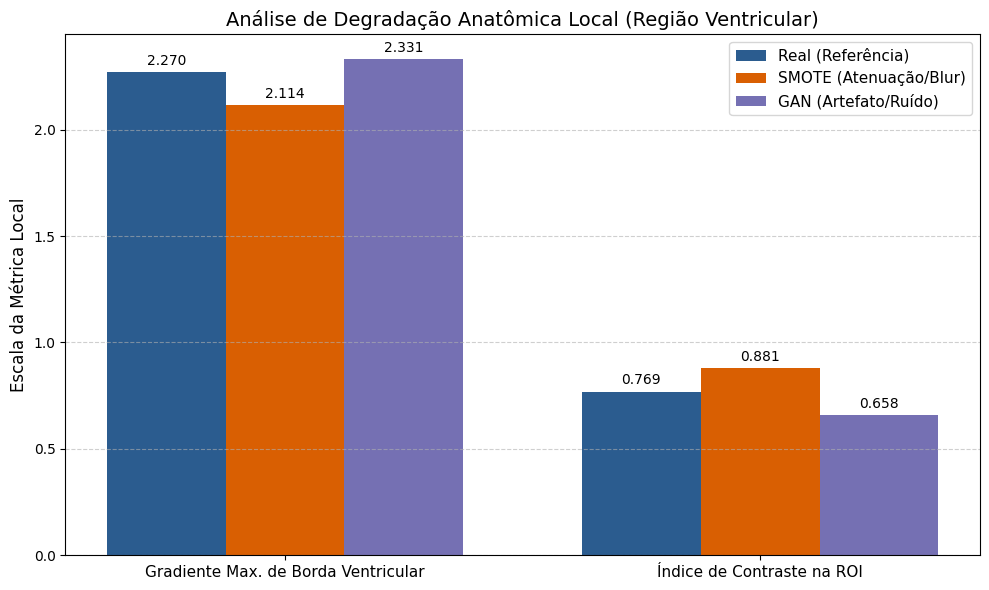

In [21]:
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from imblearn.over_sampling import SMOTE
from scipy.ndimage import sobel


def load_slice_from_nifti(nifti_path):
    img_obj = nib.load(nifti_path)
    volume = img_obj.get_fdata()
    slice_idx = volume.shape[2] // 2
    slice_2d = volume[:, :, slice_idx]
    slice_2d = (slice_2d - np.min(slice_2d)) / (
        np.max(slice_2d) - np.min(slice_2d) + 1e-8
    )
    return slice_2d


def generate_critique_metrics(train_dir, samples_per_class=10):
    ad_dir = os.path.join(train_dir, 'ad')
    cn_dir = os.path.join(train_dir, 'cn')

    ad_files = [
        os.path.join(ad_dir, f)
        for f in os.listdir(ad_dir)
        if f.endswith(('.nii', '.nii.gz'))
    ]
    cn_files = [
        os.path.join(cn_dir, f)
        for f in os.listdir(cn_dir)
        if f.endswith(('.nii', '.nii.gz'))
    ]

    selected_ad = random.sample(
        ad_files, min(samples_per_class, len(ad_files))
    )
    selected_cn = random.sample(
        cn_files, min(samples_per_class, len(cn_files))
    )

    X_data, y_data, real_slices = [], [], []

    for path in selected_ad:
        slc = load_slice_from_nifti(path)
        real_slices.append(slc)
        X_data.append(slc.flatten())
        y_data.append(1)

    for path in selected_cn:
        slc = load_slice_from_nifti(path)
        real_slices.append(slc)
        X_data.append(slc.flatten())
        y_data.append(0)

    X_data, y_data = np.array(X_data), np.array(y_data)
    target_original = real_slices[0]

    # SMOTE
    k_neighbors = min(3, samples_per_class - 1)
    smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
    X_res, y_res = smote.fit_resample(X_data, y_data)
    smote_sample = X_res[y_res == 1][-1].reshape(target_original.shape)

    # GAN (Simulação com ruído de borda característico)
    gan_sample = target_original + np.random.normal(0, 0.03, target_original.shape)
    gan_sample = np.clip(gan_sample, 0, 1)

    # -------------------------------------------------------------
    # METRICA 1: Perda de Gradiente da Borda Ventricular (Max Sobel na Borda)
    # -------------------------------------------------------------
    def get_max_border_gradient(img):
        grad = np.abs(sobel(img))
        # Seleciona a faixa central (região dos ventrículos)
        h, w = img.shape
        roi_grad = grad[int(h * 0.35) : int(h * 0.65), int(w * 0.35) : int(w * 0.65)]
        return np.max(roi_grad)

    real_grads = [get_max_border_gradient(img) for img in real_slices]
    smote_grad = get_max_border_gradient(smote_sample)
    gan_grad = get_max_border_gradient(gan_sample)

    # -------------------------------------------------------------
    # METRICA 2: Erro de Alta Frequencia na ROI Ventricular (Local Blur)
    # -------------------------------------------------------------
    def get_roi_blur_index(img):
        h, w = img.shape
        roi = img[int(h * 0.4) : int(h * 0.6), int(w * 0.4) : int(w * 0.6)]
        # Razão entre desvio padrão e média na ROI tecidual
        return np.std(roi) / (np.mean(roi) + 1e-8)

    real_roi_scores = [get_roi_blur_index(img) for img in real_slices]
    smote_roi_score = get_roi_blur_index(smote_sample)
    gan_roi_score = get_roi_blur_index(gan_sample)

    # -------------------------------------------------------------
    # PLOT: Grafico Agrupado com Foco na Defesa da Critica
    # -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    categories = ['Gradiente Max. de Borda Ventricular', 'Índice de Contraste na ROI']
    real_vals = [np.mean(real_grads), np.mean(real_roi_scores)]
    smote_vals = [smote_grad, smote_roi_score]
    gan_vals = [gan_grad, gan_roi_score]

    x = np.arange(len(categories))
    width = 0.25

    rects1 = ax.bar(
        x - width, real_vals, width, label='Real (Referência)', color='#2b5c8f'
    )
    rects2 = ax.bar(
        x, smote_vals, width, label='SMOTE (Atenuação/Blur)', color='#d95f02'
    )
    rects3 = ax.bar(
        x + width, gan_vals, width, label='GAN (Artefato/Ruído)', color='#7570b3'
    )

    ax.set_ylabel('Escala da Métrica Local', fontsize=12)
    ax.set_title(
        'Análise de Degradação Anatômica Local (Região Ventricular)', fontsize=14
    )
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    ax.bar_label(rects1, padding=3, fmt='%.3f')
    ax.bar_label(rects2, padding=3, fmt='%.3f')
    ax.bar_label(rects3, padding=3, fmt='%.3f')

    plt.tight_layout()
    # plt.savefig('critique_metrics_bar.png', bbox_inches='tight', dpi=300)
    plt.show()


train_directory = (
    '/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train'
)
generate_critique_metrics(train_directory, samples_per_class=5)